In [31]:
"""
Modelisation - Customer Personality Analysis
Input: data/processed/df_features.csv
Output: data/processed/df_features.csv

Modèles à utiliser:
    1. K-Means sans ACP
    2. K-Means avec ACP
    3. GMM avec ACP
    4. GMM avec ACP

Métrique: Silhouette Score
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")







In [32]:
# Chargement des données
PATH_DATA = "../data/processed/df_features.csv"
df = pd.read_csv(PATH_DATA)
print(f"Jeu de données {df.shape}")

Jeu de données (2212, 27)


In [33]:
# --- 1. Encodage et sélection des features

df_model = df.copy()

education_order = {
    "Basic"     : 0,
    "2n Cycle"  : 1,
    "Graduation": 2,
    "Master"    : 3,
    "PhD"       : 4,
}

df_model["Education"] = df_model["Education"].map(education_order)


marital_order = {
    "Single"  : 0,
    "Together": 1,
    "Married" : 2,
    "Divorced": 3,
    "Widow"   : 4,
}

df_model["Marital_Status"] = df_model["Marital_Status"].map(marital_order)


# Selection des features pour le clustering
cols_to_exclure = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5",
    "Complain",
    "Response",
]

features = df_model.drop(columns=cols_to_exclure)

print(f"Features pour le clustering: {features.shape[1]} colonnes")
print(features.columns.tolist())
print(features.shape)

Features pour le clustering: 20 colonnes
['Education', 'Marital_Status', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Seniority', 'Total_spend', 'Total_campaign', 'Nb_kids']
(2212, 20)


In [34]:
# --- 2. Standardisation des données ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"Moyenne après le scaling : {X_scaled.mean(axis=0).round(2)} ")
print(f"Ecart type après le scaling : {X_scaled.std(axis=0).round(2)}")

Moyenne après le scaling : [-0. -0. -0.  0.  0.  0.  0. -0.  0.  0. -0. -0. -0. -0.  0.  0. -0.  0.
 -0.  0.] 
Ecart type après le scaling : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


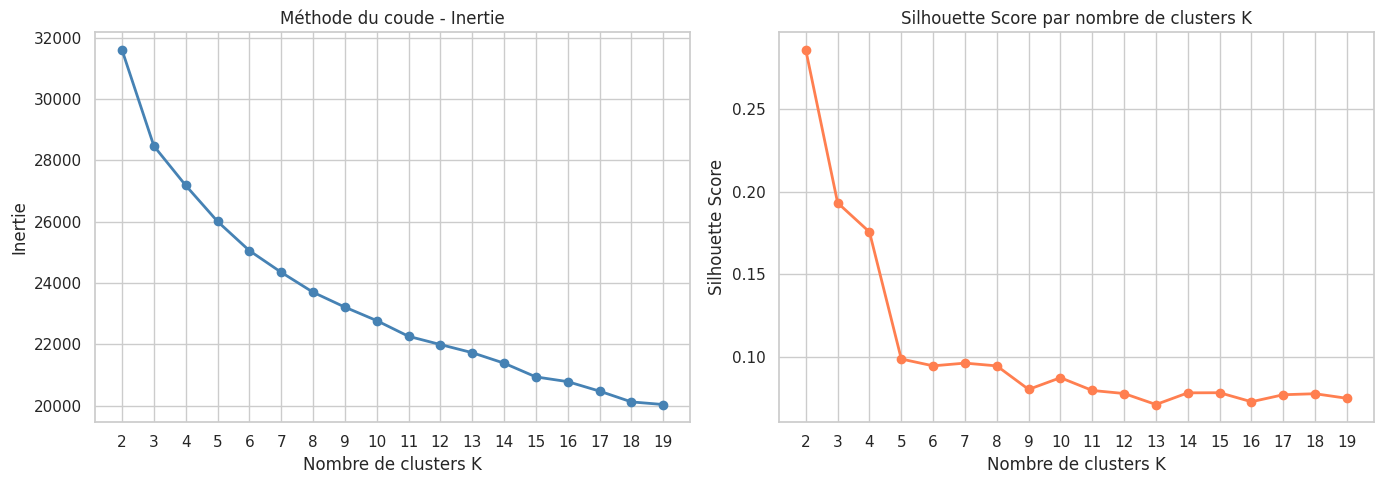


 Silhouette Scores :
2 ->: 0.2858497438548974
3 ->: 0.19335588148571384
4 ->: 0.1757195661291265
5 ->: 0.09883265382972153
6 ->: 0.0946882387938029
7 ->: 0.09635063390291355
8 ->: 0.09467044283363028
9 ->: 0.08042784089253596
10 ->: 0.08751690611817173
11 ->: 0.07979237879131629
12 ->: 0.07793610885048455
13 ->: 0.07127806325598089
14 ->: 0.0783506368434057
15 ->: 0.07842549741953744
16 ->: 0.07295898120063495
17 ->: 0.07720668897481635
18 ->: 0.07781469724427821
19 ->: 0.0750438608497908


In [41]:
# --- 3. Choix du K optimal sans ACP
K_range = range(2,20)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))


# Visualisation
figure, axes = plt.subplots(1, 2, figsize=(14,5))

# Coude
axes[0].plot(K_range, inertias, marker = "o", color="steelblue", linewidth=2)
axes[0].set_xticks(K_range)
axes[0].set_title("Méthode du coude - Inertie")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("Inertie")

# Silhouette
axes[1].plot(K_range, silhouettes, marker = "o", color="coral", linewidth=2)
axes[1].set_xticks(K_range)
axes[1].set_title("Silhouette Score par nombre de clusters K")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


print("\n Silhouette Scores :")
for k, s in zip(K_range, silhouettes):
    print(f"{k} ->: {s}")


Dimension avant l'ACP: 20
Dimension après ACP:  13
Variance expliquée : 0.91


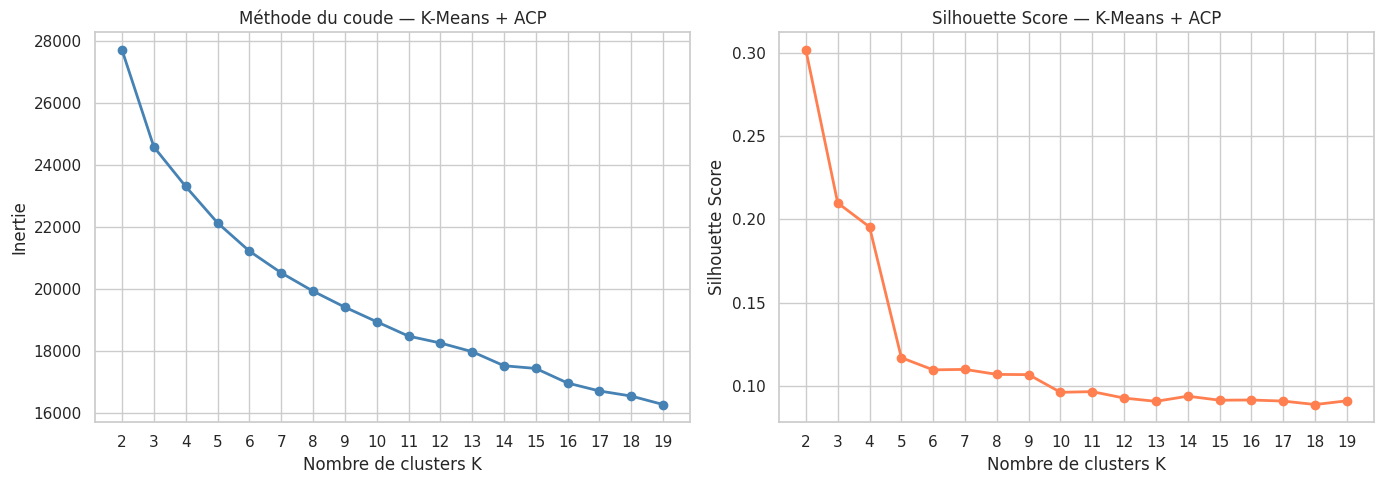


Silhouette Scores K-Means + ACP :
  K=2 → 0.3016
  K=3 → 0.2099
  K=4 → 0.1955
  K=5 → 0.1171
  K=6 → 0.1098
  K=7 → 0.1101
  K=8 → 0.1071
  K=9 → 0.1069
  K=10 → 0.0963
  K=11 → 0.0967
  K=12 → 0.0929
  K=13 → 0.0909
  K=14 → 0.0940
  K=15 → 0.0916
  K=16 → 0.0917
  K=17 → 0.0911
  K=18 → 0.0890
  K=19 → 0.0912


In [42]:
# --- Choix su K optimal avec ACP

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimension avant l'ACP: {X_scaled.shape[1]}")
print(f"Dimension après ACP:  {X_pca.shape[1]}")
print(f"Variance expliquée : {pca.explained_variance_ratio_.sum().round(2)}")


K_range = range(2,20)
inertias = []
silhouettes = []


for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))


figure, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(K_range, inertias, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("Méthode du coude — K-Means + ACP")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_xticks(K_range)
axes[0].set_ylabel("Inertie")

axes[1].plot(K_range, silhouettes, marker="o", color="coral", linewidth=2)
axes[1].set_title("Silhouette Score — K-Means + ACP")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_xticks(K_range)
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

print("\nSilhouette Scores K-Means + ACP :")
for k, s in zip(K_range, silhouettes):
    print(f"  K={k} → {s:.4f}")


In [38]:
# --- Modèle final: K-Means + ACP, K=3

# Configuration

final_cols_to_exclure = cols_to_exclure

features = df_model.drop(columns=final_cols_to_exclure)

# Standardisation
scaler = StandardScaler()
X_n = scaler.fit_transform(features)


# ACP
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_n)


# Modèle final
K_final = 3
km_final = KMeans(n_clusters=K_final, random_state=42, n_init=10)
labels = km_final.fit_predict(X_pca)

# Ajout des labels au dataframe original
df_model["Cluster"] = labels


# Distribution des clusters
print("Distribution des clusters: ")
print(df_model["Cluster"].value_counts().sort_index())
print(f"\n Silhouette Score final: {silhouette_score(X_pca, labels):.4f}")

Distribution des clusters: 
Cluster
0     634
1    1029
2     549
Name: count, dtype: int64

 Silhouette Score final: 0.2330


In [39]:
# -- Interpretation

cols_profil = [
    "Income", "Age", "Total_spend",
    "MntWines", "MntMeatProducts", "MntGoldProds",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "Total_campaign", "Recency", "Nb_kids", "Cluster"
]

profil = df_model[cols_profil].groupby("Cluster").mean().round(1)
print(profil.T)

Cluster                    0        1        2
Income               75309.3  35186.8  56429.2
Age                     45.8     42.5     49.2
Total_spend           1353.3     97.9    700.5
MntWines               608.5     41.8    449.0
MntMeatProducts        434.4     22.8    128.5
MntGoldProds            78.3     15.3     57.9
NumWebPurchases          5.3      2.1      6.5
NumCatalogPurchases      5.9      0.6      2.9
NumStorePurchases        8.4      3.2      7.6
Total_campaign           1.0      0.2      0.4
Recency                 49.4     49.4     48.0
Nb_kids                  0.3      1.2      1.2


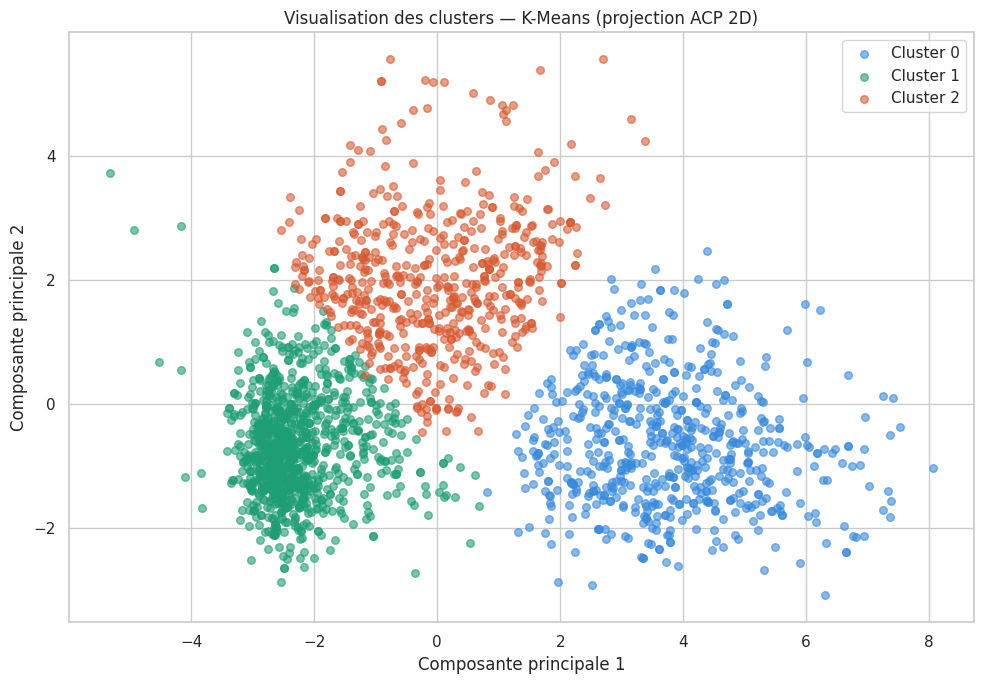

In [40]:
# --- Visualisation 2D --

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_n)

plt.figure(figsize=(10, 7))
colors = ["#378ADD", "#1D9E75", "#D85A30", "#BA7517"]

for cluster in range(K_final):
    mask = labels == cluster
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[cluster],
        label=f"Cluster {cluster}",
        alpha=0.6, s=30
    )

plt.title("Visualisation des clusters — K-Means (projection ACP 2D)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.tight_layout()
plt.show()

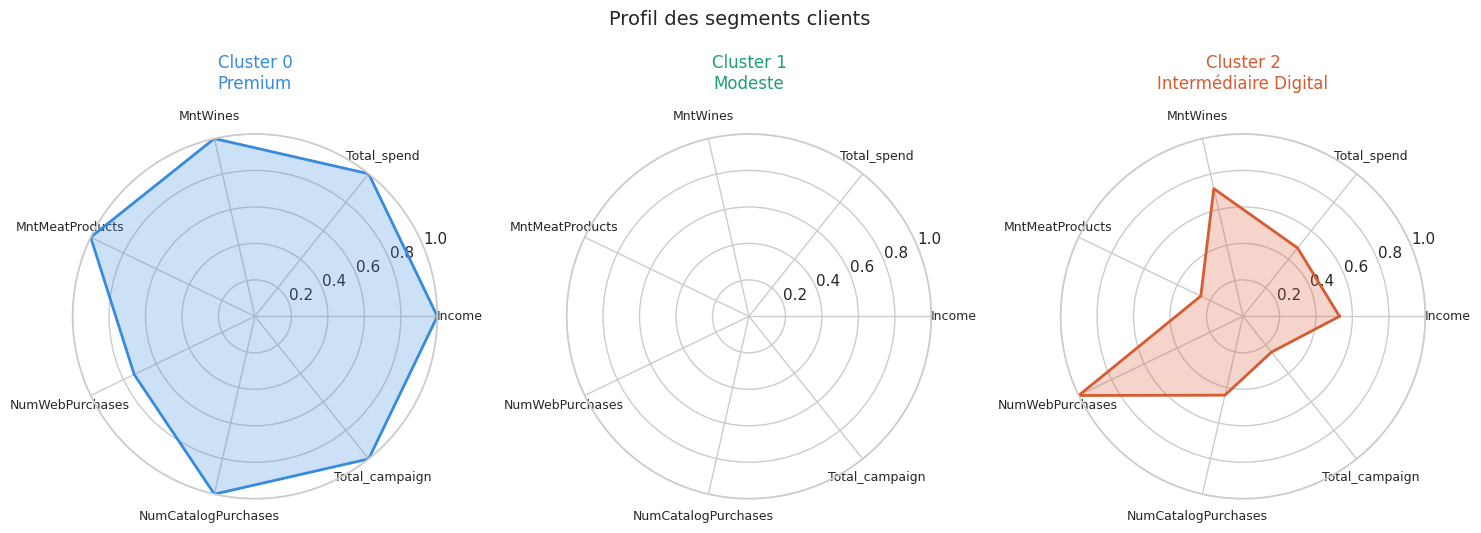

In [43]:
# --- RADAR CHART — profil des clusters ---
import numpy as np

cols_radar = [
    "Income", "Total_spend", "MntWines", "MntMeatProducts",
    "NumWebPurchases", "NumCatalogPurchases", "Total_campaign"
]

# Normalisation entre 0 et 1 pour comparer
profil_norm = df_model.groupby("Cluster")[cols_radar].mean()
profil_norm = (profil_norm - profil_norm.min()) / (profil_norm.max() - profil_norm.min())

# Paramètres radar
N = len(cols_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fermer le polygone

fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                          subplot_kw=dict(polar=True))

colors  = ["#378ADD", "#1D9E75", "#D85A30"]
noms    = ["Premium", "Modeste", "Intermédiaire Digital"]

for i, ax in enumerate(axes):
    values = profil_norm.iloc[i].tolist()
    values += values[:1]

    ax.plot(angles, values, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cols_radar, size=9)
    ax.set_title(f"Cluster {i}\n{noms[i]}", size=12,
                 color=colors[i], pad=15)
    ax.set_ylim(0, 1)

plt.suptitle("Profil des segments clients", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()